In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import metrics
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import joblib

In [2]:
data = pd.read_csv("full_scaled.csv")

In [3]:
# Remove target variable before clustering
X_scaled = data.drop(columns=["Churn"])

In [4]:
X_scaled.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges
0,1,0,1,0.013889,1,0,0,2,0.415842
1,0,0,0,0.416667,1,0,0,1,0.366337
2,0,1,0,0.638889,1,1,1,0,0.811881
3,1,0,0,0.597222,1,0,0,1,0.475248
4,1,0,0,0.013889,1,1,1,2,0.019802


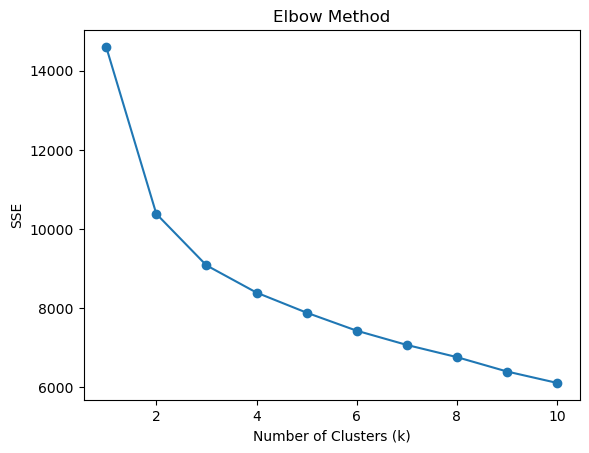

In [5]:
# ==================== elbow method =========================
sse = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
    
plt.plot(k_range, sse, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.show()

In [6]:
# check variance of each variable
print(X_scaled.std().sort_values())

PhoneService       0.295752
MonthlyCharges     0.297937
tenure             0.341104
SeniorCitizen      0.368612
Dependents         0.458110
MultipleLines      0.493888
InternetService    0.496372
gender             0.500013
Contract           0.833755
dtype: float64


In [7]:
# use silhouette score to check optimal number 
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette score={score:.4f}")

k=2, silhouette score=0.2618
k=3, silhouette score=0.2065
k=4, silhouette score=0.2009
k=5, silhouette score=0.1740
k=6, silhouette score=0.1709
k=7, silhouette score=0.1706
k=8, silhouette score=0.1842
k=9, silhouette score=0.1890
k=10, silhouette score=0.2084


In [8]:
# KMeans clustering
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

In [9]:
# save our trained K-Means model into a file
joblib.dump(kmeans, "kmeans_model.pkl")
print("KMeans model saved as kmeans_model.pkl")

KMeans model saved as kmeans_model.pkl


In [10]:
# ======================== Add cluster labels =========================
data["Cluster"] = labels
print("\nCluster counts:")
print(pd.Series(labels).value_counts().sort_index())


Cluster counts:
0    2435
1    1941
2    2667
Name: count, dtype: int64



PCA 2D explained variance ratio:
[0.347098   0.15969691]
Total explained variance (2 components): 0.5067949017502861


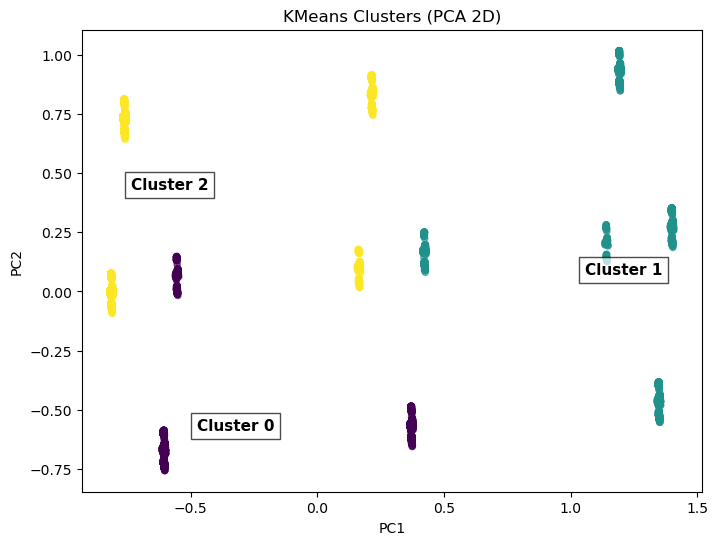

In [11]:
# ======================== PCA for Visualisation =========================
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

print("\nPCA 2D explained variance ratio:")
print(pca_2d.explained_variance_ratio_)
print("Total explained variance (2 components):", pca_2d.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="viridis", s=20, alpha=0.6)

for i in np.unique(labels):
    x_center = X_2d[labels == i, 0].mean()
    y_center = X_2d[labels == i, 1].mean()
    plt.text(
        x_center, y_center, f"Cluster {i}",
        fontsize=11, fontweight="bold",
        ha="center", va="center",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters (PCA 2D)")
plt.show()


In [12]:
# ======================== cluster_profile =========================
data["Cluster"] = labels
# numeric profile
cluster_profile = data.groupby("Cluster").mean()
print("\nCluster profile:\n")
print(cluster_profile.T)


Cluster profile:

Cluster                 0         1         2
gender           0.475154  0.515198  0.524184
SeniorCitizen    0.168789  0.158166  0.158980
Dependents       0.289528  0.293663  0.313086
tenure           0.442608  0.449339  0.456172
PhoneService     0.899384  0.906234  0.904387
MultipleLines    0.108830  0.576507  0.595051
InternetService  0.000000  0.221020  1.000000
Contract         0.282546  1.873261  0.202100
MonthlyCharges   0.463139  0.468514  0.458750
Churn            0.280493  0.252447  0.260967



Churn rate by cluster:

Cluster
0    0.280493
1    0.252447
2    0.260967
Name: Churn, dtype: float64


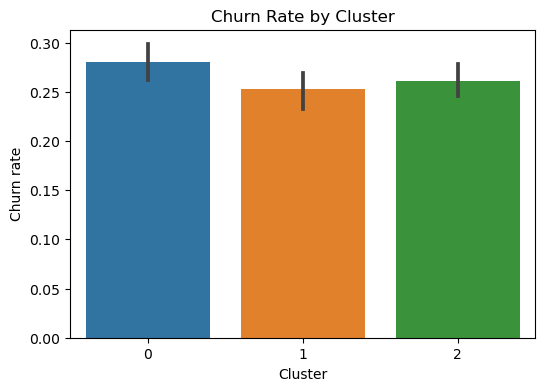

In [13]:
# ======================== Churn rate =========================
churn_rate = data.groupby("Cluster")["Churn"].mean()
print("\nChurn rate by cluster:\n")
print(churn_rate)

plt.figure(figsize=(6, 4))
sns.barplot(x="Cluster", y="Churn", data=data)
plt.title("Churn Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Churn rate")
plt.show()

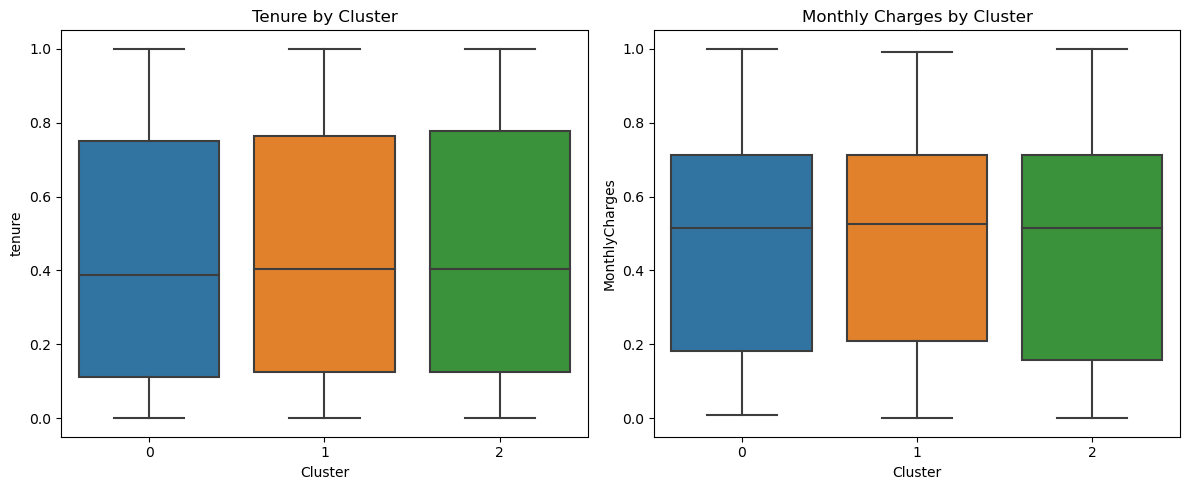

In [14]:
# ======================== Key Variable Boxplots =========================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x="Cluster", y="tenure", data=data)
plt.title("Tenure by Cluster")

plt.subplot(1, 2, 2)
sns.boxplot(x="Cluster", y="MonthlyCharges", data=data)
plt.title("Monthly Charges by Cluster")

plt.tight_layout()
plt.show()